In [35]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.impute import KNNImputer

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [36]:
data = pd.read_csv('../data/base.csv', delimiter=",")
display(data.head())
display(data.info())

,fecha,referencia,alcalinidad_total,aluminio,bario,bicarbonatos,cadmio,calcio,carbonatos,cianuro_libre,...,solidos_sedimentables,solidos_suspendidos,solidos_totales,solidos_totales_volátiles,sulfatos,sulfuros,sustancias_solubles_al_hexano,turbiedad,zinc,obs
0,04/06/2001,P1,154.80,NaN,NaN,NaN,0.50,NaN,NaN,NaN,...,0.3,41,313,NaN,10.65,NaN,0.0,17,0.1353,NaN
1,04/06/2001,P2,161.90,NaN,NaN,NaN,0.50,NaN,NaN,NaN,...,0.9,185,453,NaN,16.36,NaN,18.0,40,0.09056,NaN
2,04/06/2001,P3,160.90,NaN,NaN,NaN,0.50,NaN,NaN,NaN,...,0.7,209,470,NaN,18.33,NaN,15.0,52,0.09999,NaN
3,04/06/2001,P4,159.70,NaN,NaN,NaN,0.50,NaN,NaN,NaN,...,0.2,74,350,NaN,23.95,NaN,6.0,26,0.09698,NaN
4,04/07/2001,P1,153.70,169.7,NaN,NaN,0.50,NaN,NaN,NaN,...,0,0,293,NaN,0,NaN,14.5,NaN,0.1172,NaN


<class 'pandas.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   fecha                          640 non-null    str    
 1   referencia                     640 non-null    str    
 2   alcalinidad_total              93 non-null     str    
 3   aluminio                       233 non-null    str    
 4   bario                          12 non-null     str    
 5   bicarbonatos                   71 non-null     str    
 6   cadmio                         404 non-null    str    
 7   calcio                         13 non-null     str    
 8   carbonatos                     71 non-null     str    
 9   cianuro_libre                  121 non-null    float64
 10  cloruros                       27 non-null     str    
 11  cobre                          374 non-null    str    
 12  coliformes_termotolerantes     550 non-null    str    
 13  c

None

In [37]:
# Ajustes de base de datos
# 1. Convertir todo lo posible a numérico, ignorando errores (los vuelve NaN)
cols_a_limpiar = data.columns.drop(['fecha', 'referencia', 'obs'])
for col in cols_a_limpiar:
    data[col] = pd.to_numeric(data[col].astype(str).str.replace(',', '.').str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

# 2. Eliminar columnas con más del 50% de nulos
umbral = len(data) * 0.50
data_fixed = data.copy().dropna(thresh=umbral, axis=1)

data_fixed.head()
data_fixed.info()

<class 'pandas.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   fecha                       640 non-null    str    
 1   referencia                  640 non-null    str    
 2   cadmio                      404 non-null    float64
 3   cobre                       374 non-null    float64
 4   coliformes_termotolerantes  530 non-null    float64
 5   coliformes_totales          542 non-null    float64
 6   cromo                       409 non-null    float64
 7   dbo5                        577 non-null    float64
 8   dqo                         611 non-null    float64
 9   hierro                      383 non-null    float64
 10  manganeso                   350 non-null    float64
 11  niquel                      388 non-null    float64
 12  ph                          593 non-null    float64
 13  plomo                       404 non-null    fl

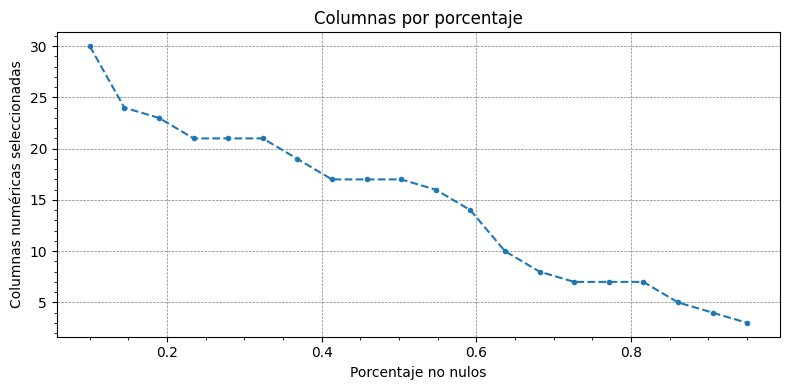

In [68]:
range_umbral = np.linspace(0.1,0.95,20)

columns_per_perc = np.zeros([len(range_umbral), 2])

i = 0 
for umbral in range_umbral:
    # 2. Eliminar columnas con más del 50% de nulos
    umbral_len = len(data) * umbral
    data_fixed = data.copy().dropna(thresh=umbral_len, axis=1)
    columns_per_perc[i, 0] = umbral
    columns_per_perc[i, 1] = len(data_fixed.columns)
    i += 1

# sns.lineplot(x=columns_per_perc[:,0], y=columns_per_perc[:,1], palette='viridis', alpha=1)

# print(columns_per_perc)
plt.figure(figsize=(8,4))
plt.plot(columns_per_perc[:, 0], columns_per_perc[:, 1], '--.')
plt.minorticks_on()
plt.grid(which='major', linestyle='--', linewidth='0.5', color='gray')
plt.title("Columnas por porcentaje")
plt.xlabel("Porcentaje no nulos")
plt.ylabel("Columnas numéricas seleccionadas")
plt.tight_layout()  # Prevents overlapv
plt.show()

In [39]:
# 3. Imputar nulos restantes con la mediana (simple y robusto)
# data_fixed = data_fixed.fillna(data.median(numeric_only=True))

# Definimos el imputador (n_neighbors=5 es un buen estándar)
imputer = KNNImputer(n_neighbors=5)

# Seleccionamos solo las columnas numéricas que sobrevivieron a la limpieza
cols_numericas = data_fixed.select_dtypes(include=[np.number]).columns

# Solo aplicamos a las columnas numéricas que decidiste conservar
data_imputed = imputer.fit_transform(data_fixed[cols_numericas])

# Convertimos de nuevo a DataFrame
data_fixed = pd.DataFrame(data_imputed, columns=cols_numericas)
data_fixed['fecha'] = data['fecha']
data_fixed['referencia'] = data['referencia']

data_fixed.head()

ValueError: at least one array or dtype is required

In [ ]:
data_fixed.info()

<class 'pandas.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   aluminio                       640 non-null    float64
 1   cadmio                         640 non-null    float64
 2   cianuro_libre                  640 non-null    float64
 3   cobre                          640 non-null    float64
 4   coliformes_termotolerantes     640 non-null    float64
 5   coliformes_totales             640 non-null    float64
 6   conductividad                  640 non-null    float64
 7   cromo                          640 non-null    float64
 8   dbo5                           640 non-null    float64
 9   dqo                            640 non-null    float64
 10  fosforo_total                  640 non-null    float64
 11  hierro                         640 non-null    float64
 12  manganeso                      640 non-null    float64
 13  n

In [ ]:
display(data_fixed.describe())
data_fixed.to_csv("./results/data_fixed.csv", index=False)

,aluminio,cadmio,cianuro_libre,cobre,coliformes_termotolerantes,coliformes_totales,conductividad,cromo,dbo5,dqo,...,manganeso,niquel,nitratos,nitritos,ph,plomo,solidos_suspendidos,solidos_totales,sustancias_solubles_al_hexano,zinc
count,640.000000,640.000000,640.000000,640.000000,6.400000e+02,6.400000e+02,640.000000,640.000000,640.000000,640.000000,...,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000
mean,898.403018,14.898495,0.839667,47.899468,1.072054e+05,2.151794e+05,18.186403,213.768437,44.135028,29.832351,...,2.968841,190.440644,0.319774,7.377475,7.967212,81.584636,247.613513,198.115416,30.713020,1.783904
std,3429.672945,28.127018,0.236827,60.670434,5.464733e+05,1.016379e+06,6.602917,223.522054,127.096585,74.083579,...,8.137076,164.820791,0.302916,16.609756,0.562990,72.326645,231.165202,637.962032,19.645109,13.738645
min,1.009000,0.500000,0.000000,1.000000,1.600000e+00,1.600000e+00,0.440000,1.020000,0.000000,1.085000,...,0.001000,1.117000,0.000000,0.000000,5.480000,1.026000,0.000000,2.164000,0.000000,0.000800
25%,9.632600,10.000000,0.800000,10.000000,9.300000e+02,2.550000e+03,13.476000,20.000000,1.000000,9.133800,...,0.068975,50.000000,0.104300,0.003800,7.720000,50.000000,37.000000,14.600600,13.580000,0.044550
50%,156.274900,10.100000,1.000000,33.555000,3.300000e+03,1.300000e+04,17.741000,152.323985,3.450000,20.309800,...,0.607790,171.120000,0.219000,0.027600,8.080000,64.070000,227.322000,18.107000,33.750000,0.488140
75%,440.544850,14.540000,1.000000,55.977500,2.818658e+04,6.009524e+04,21.313000,323.342900,13.562500,28.065250,...,1.701500,303.948150,0.474150,8.485500,8.340000,99.080000,372.480000,347.500000,44.820000,1.291000
max,64810.000000,482.800000,1.070000,569.140000,1.100000e+07,1.700000e+07,53.100000,989.200000,990.000000,891.000000,...,84.600000,970.400000,2.910000,257.500000,9.080000,670.400000,2320.000000,13710.000000,223.000000,332.000000


C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


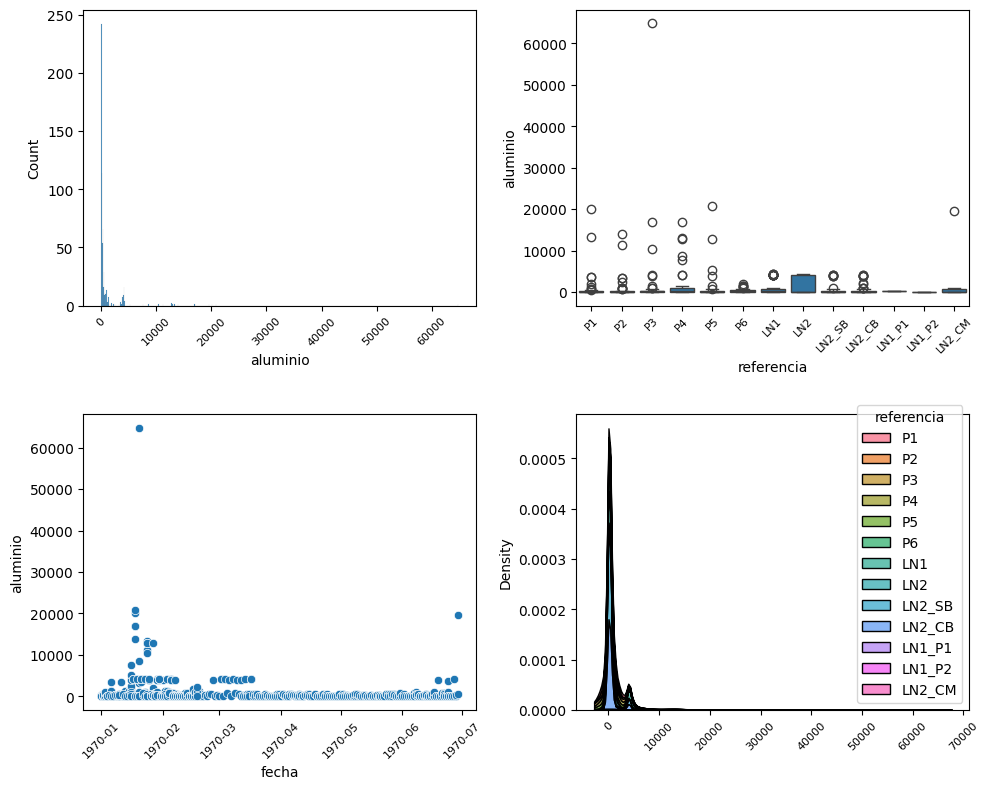

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


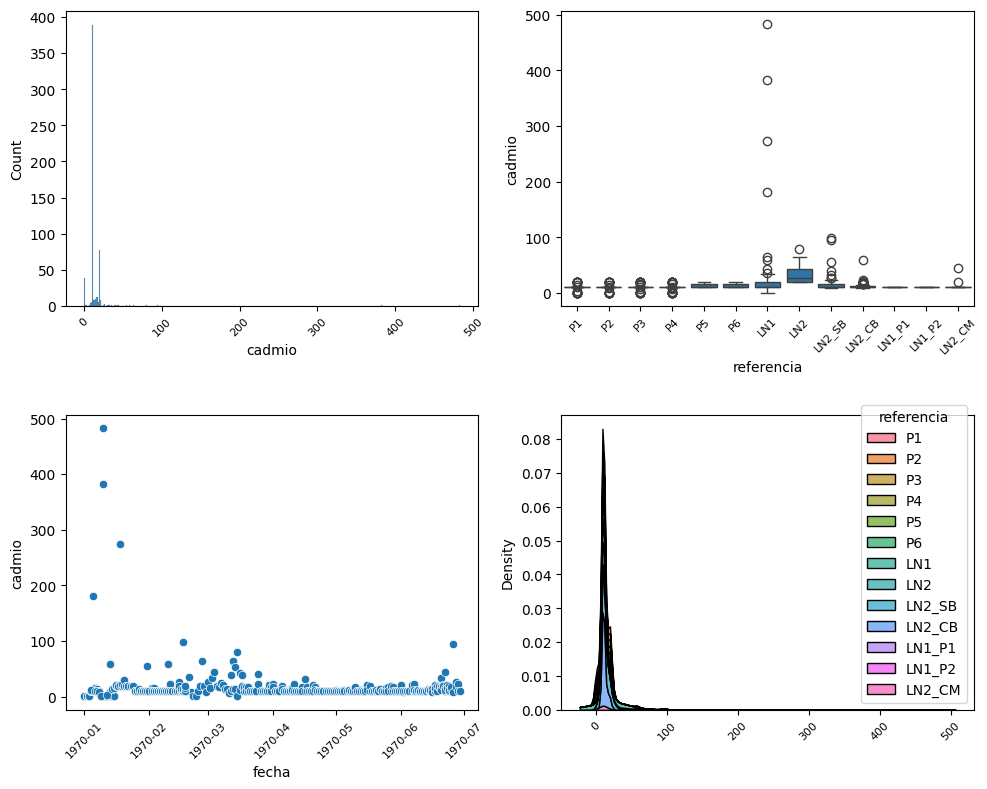

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


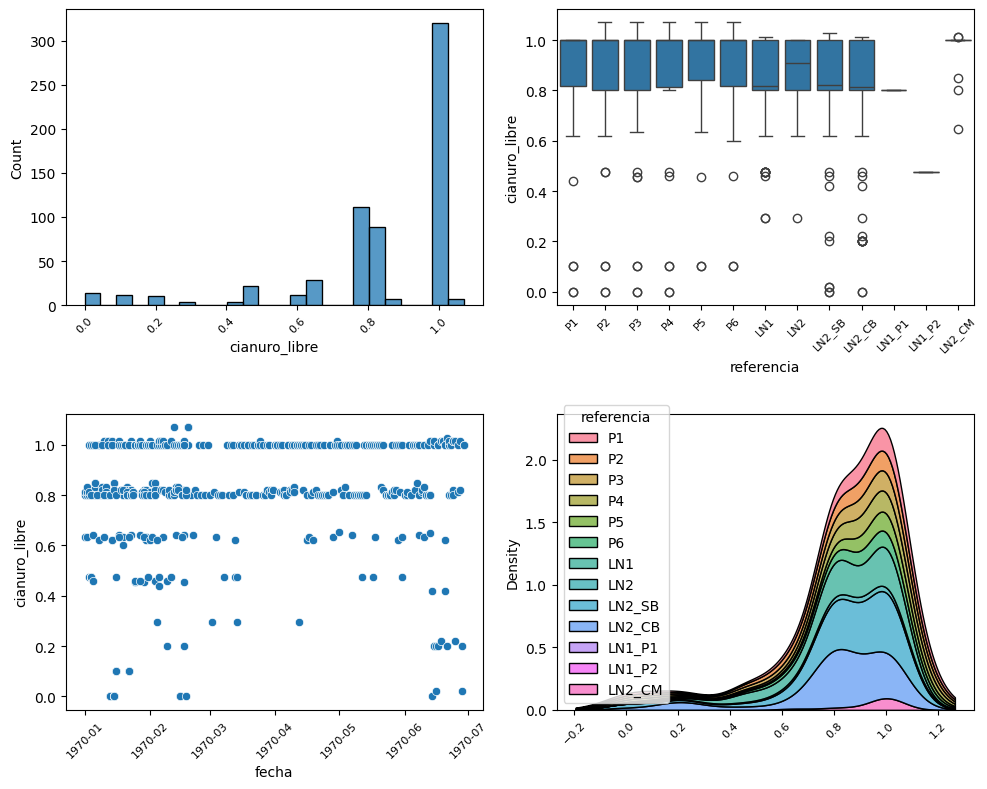

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


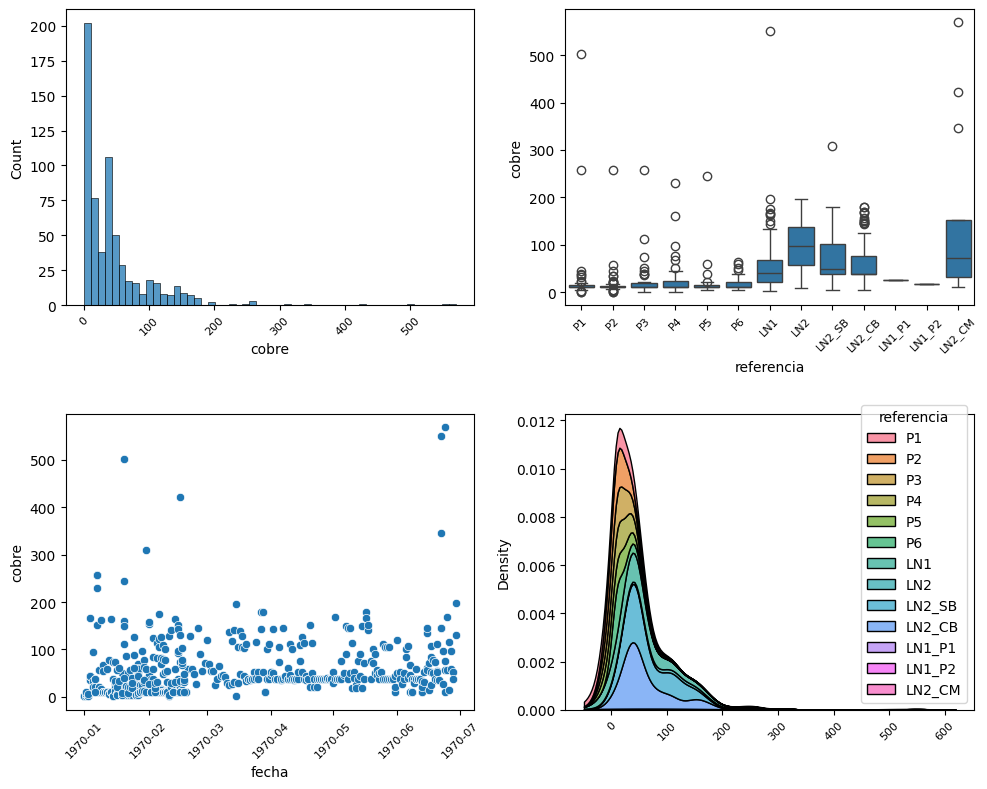

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


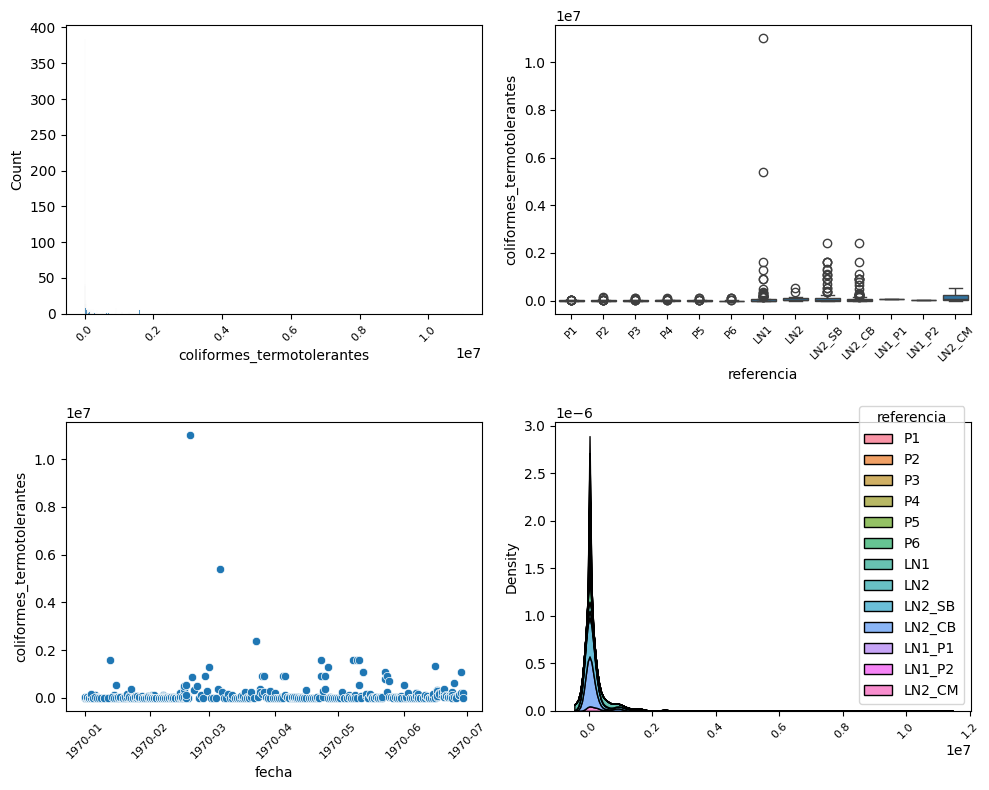

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


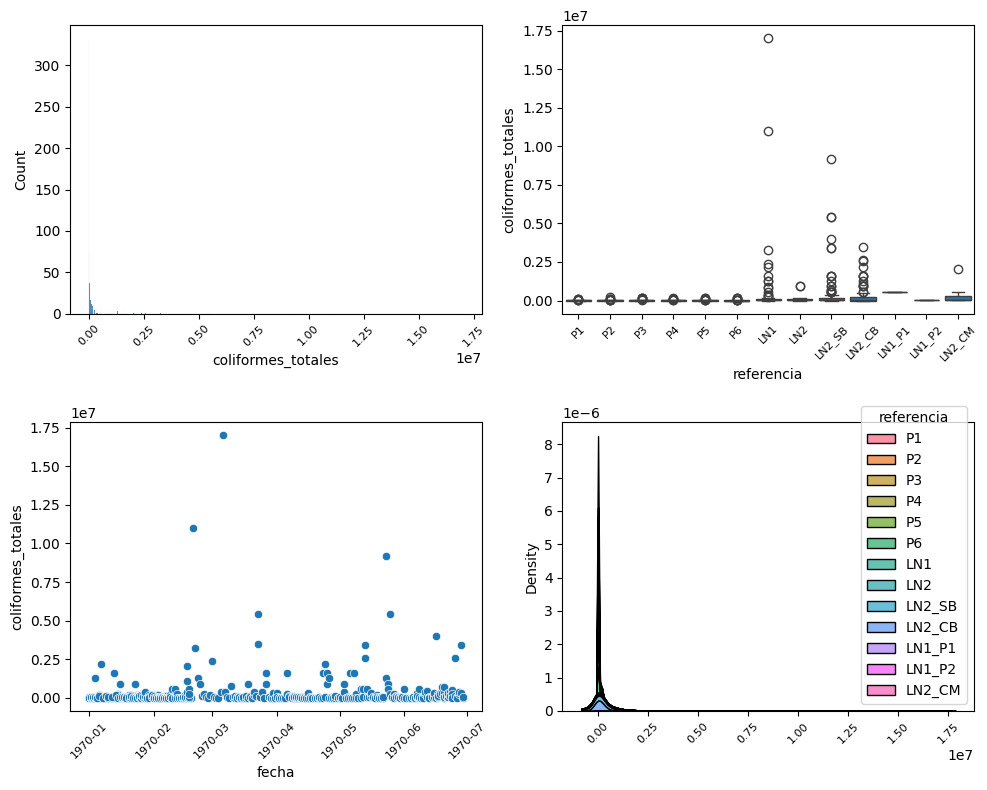

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


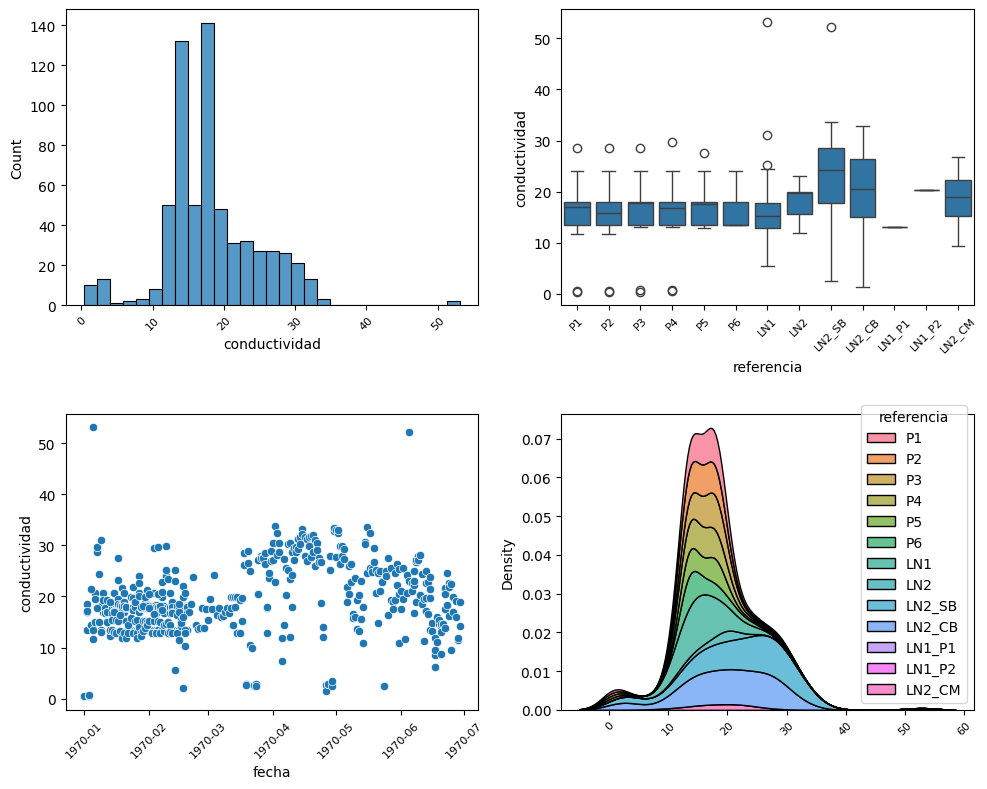

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


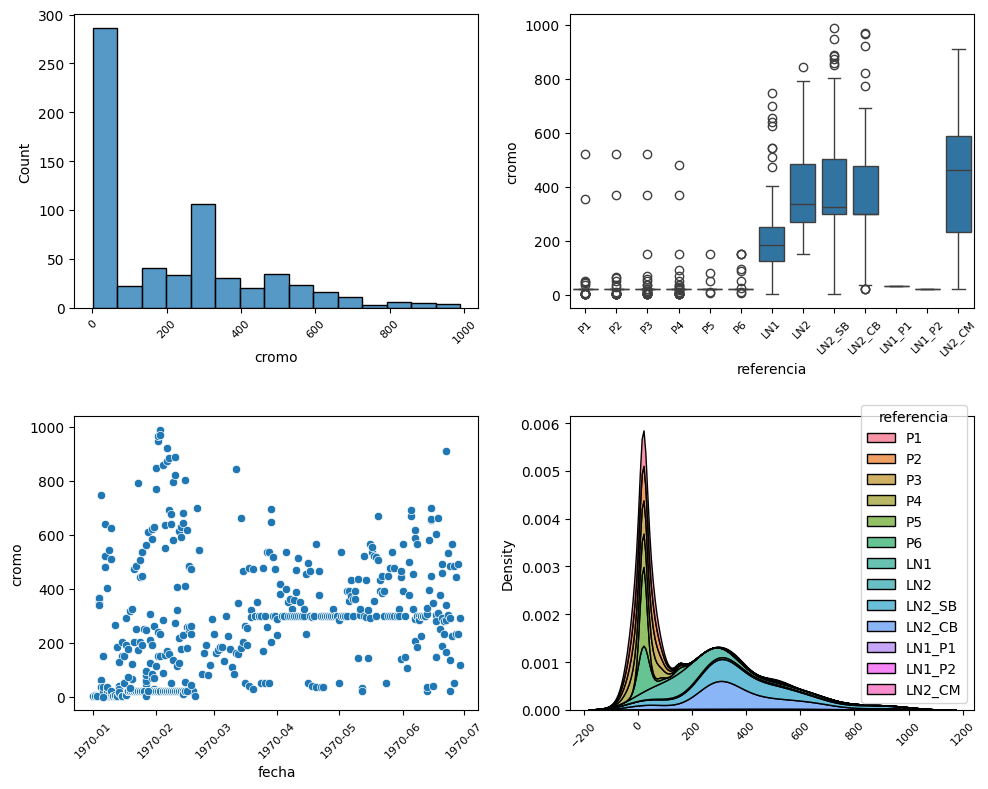

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


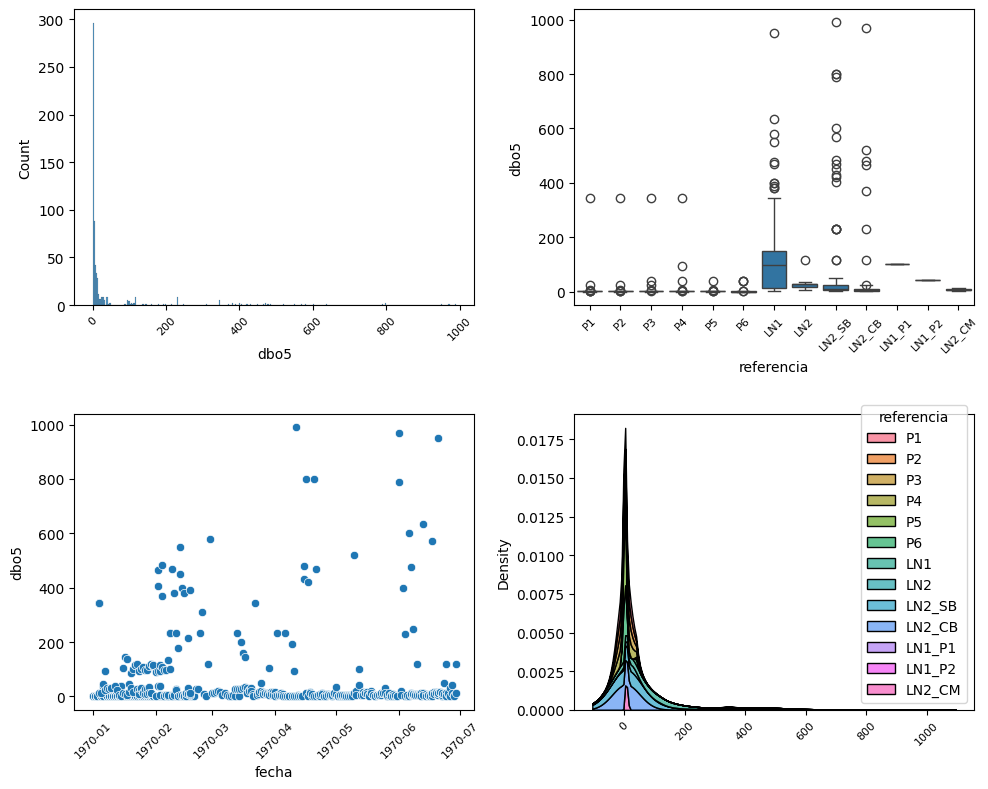

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


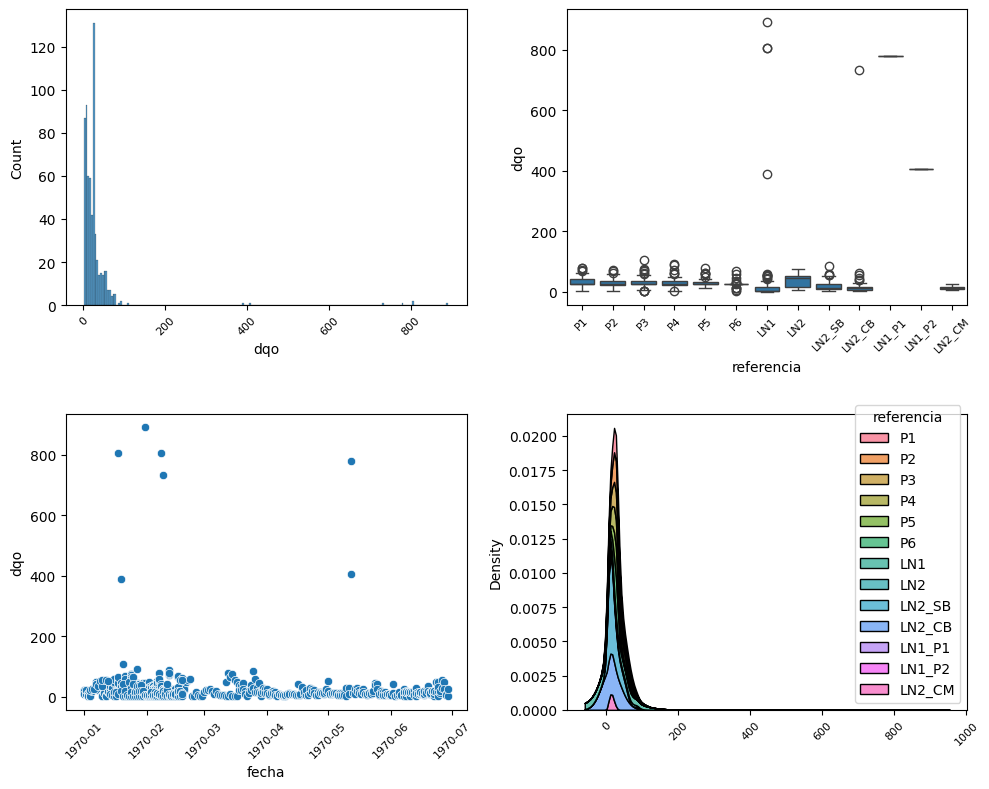

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


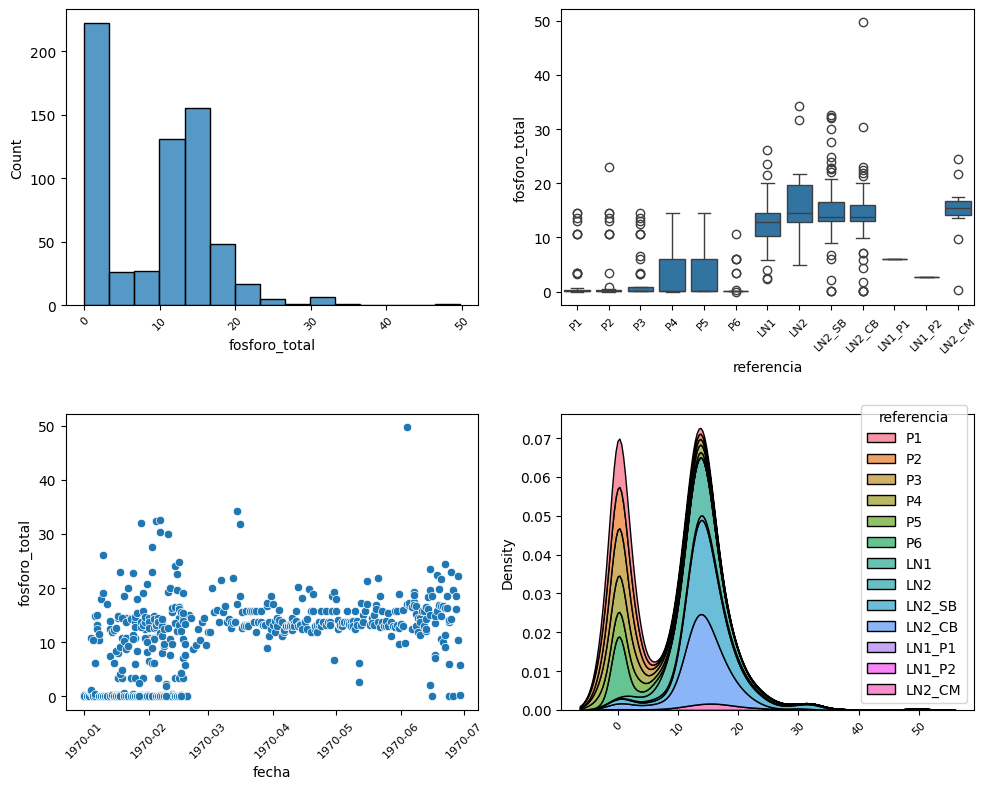

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


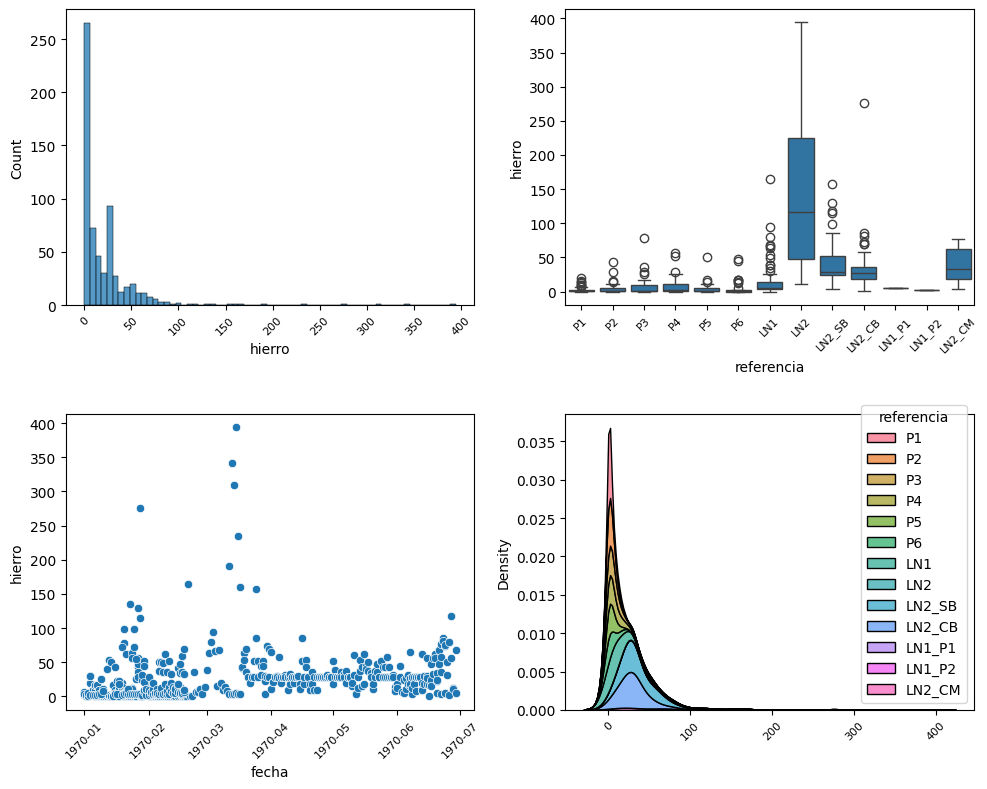

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


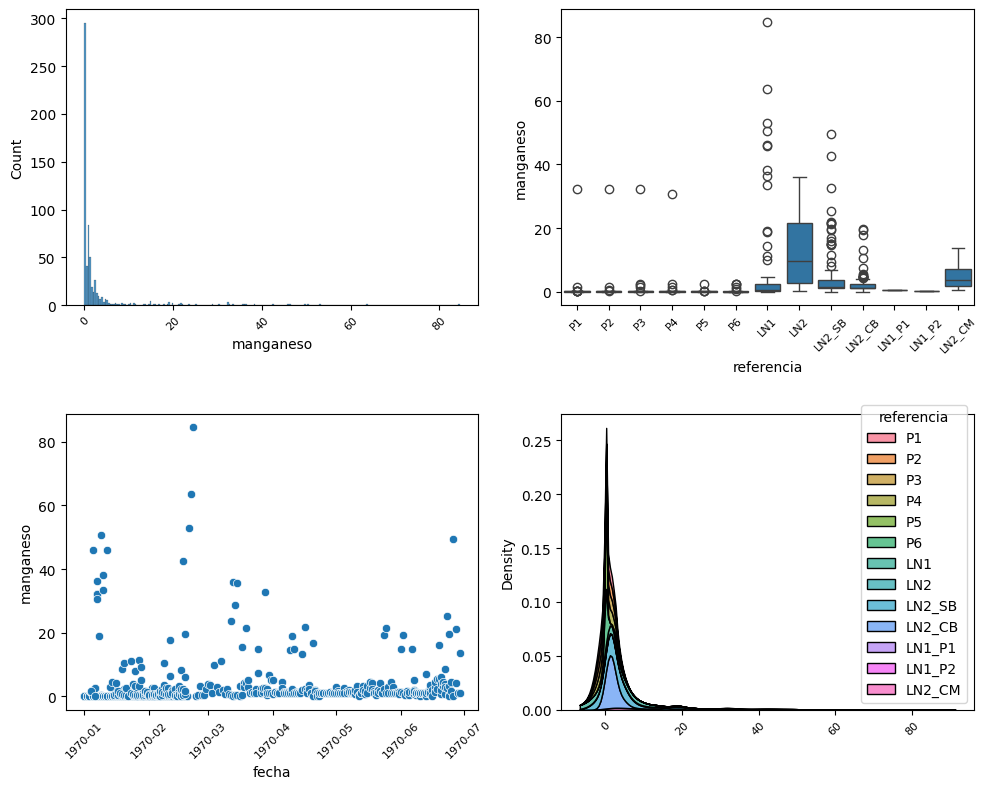

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


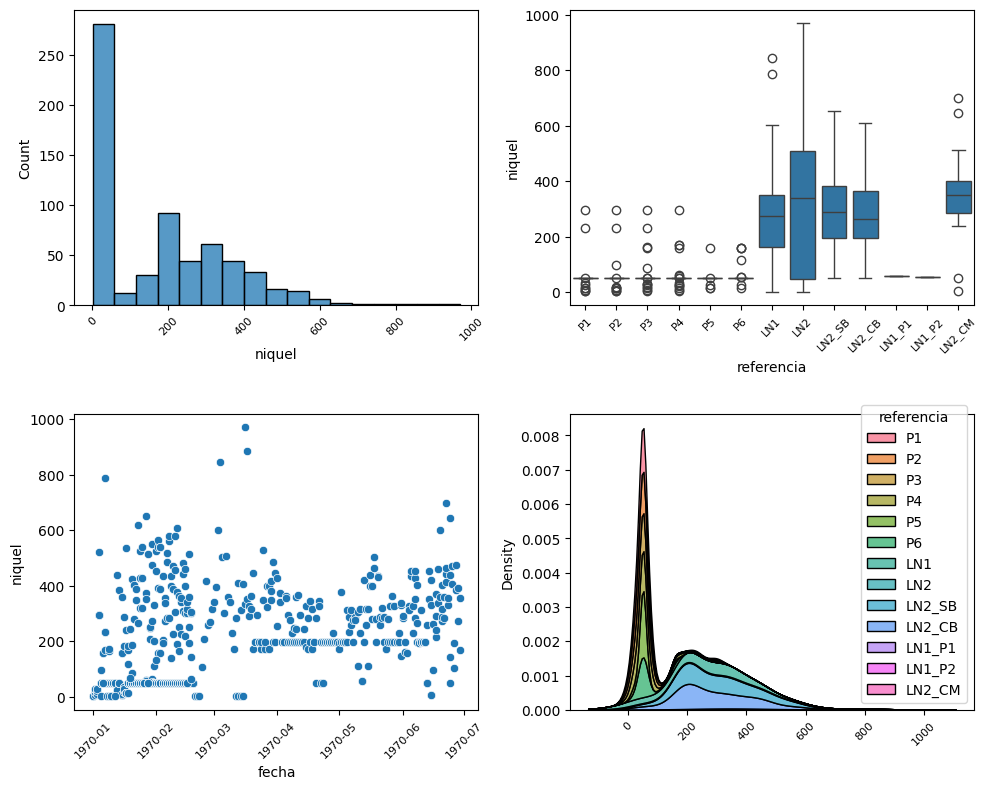

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


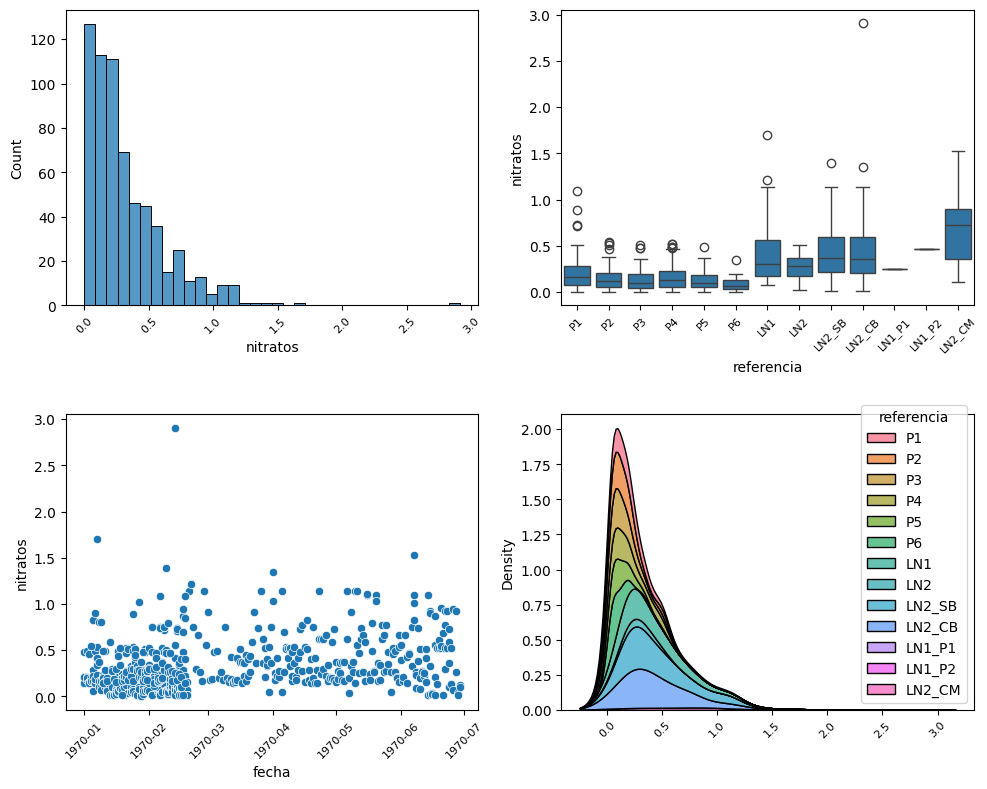

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


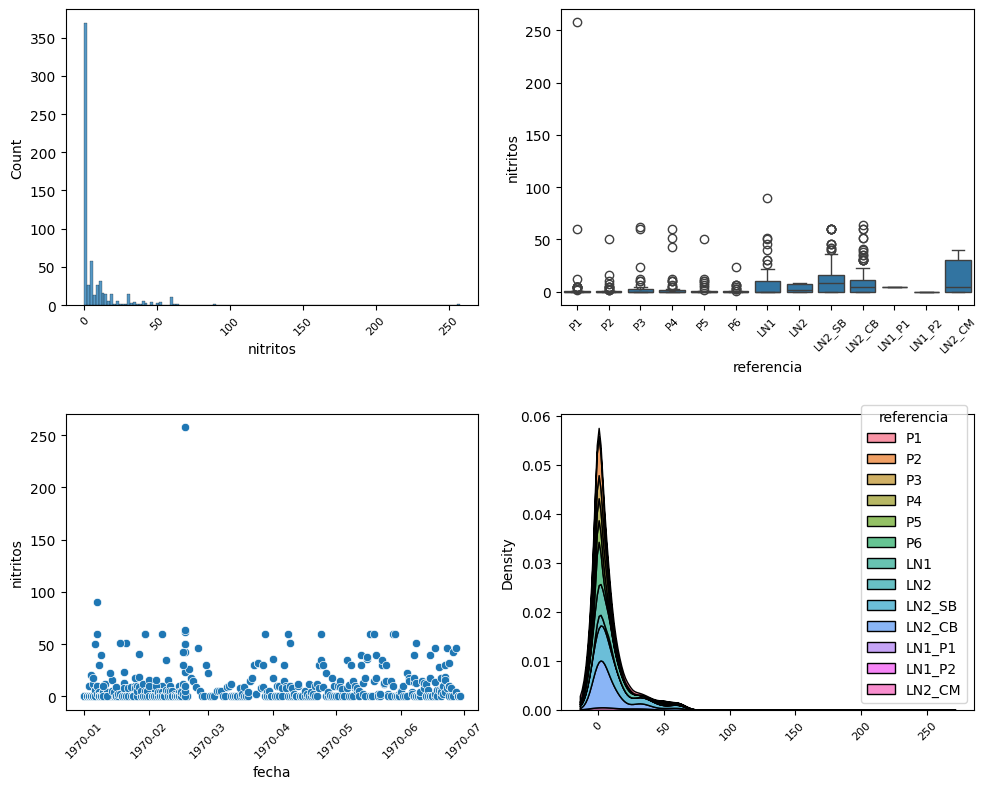

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


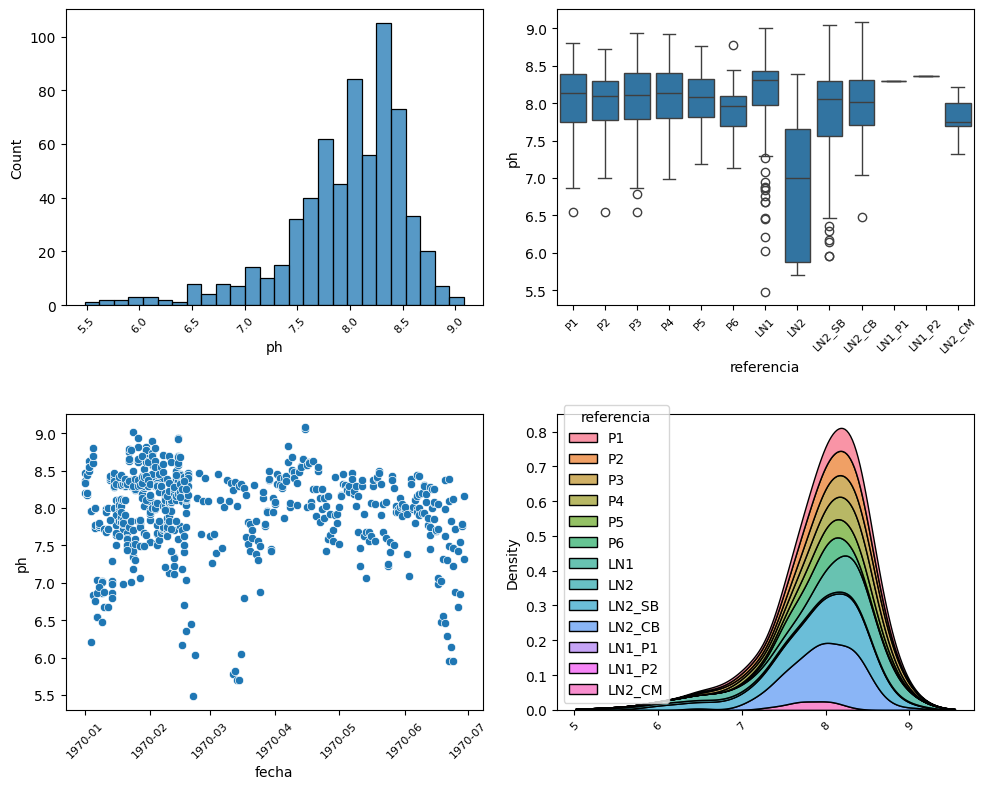

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


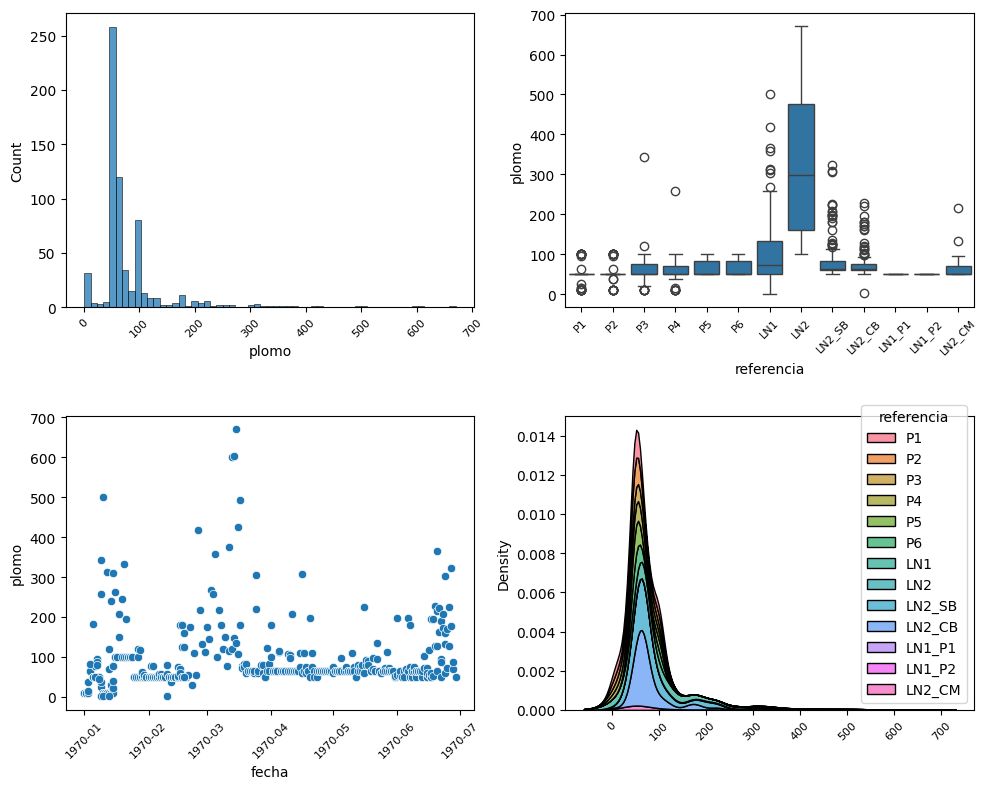

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


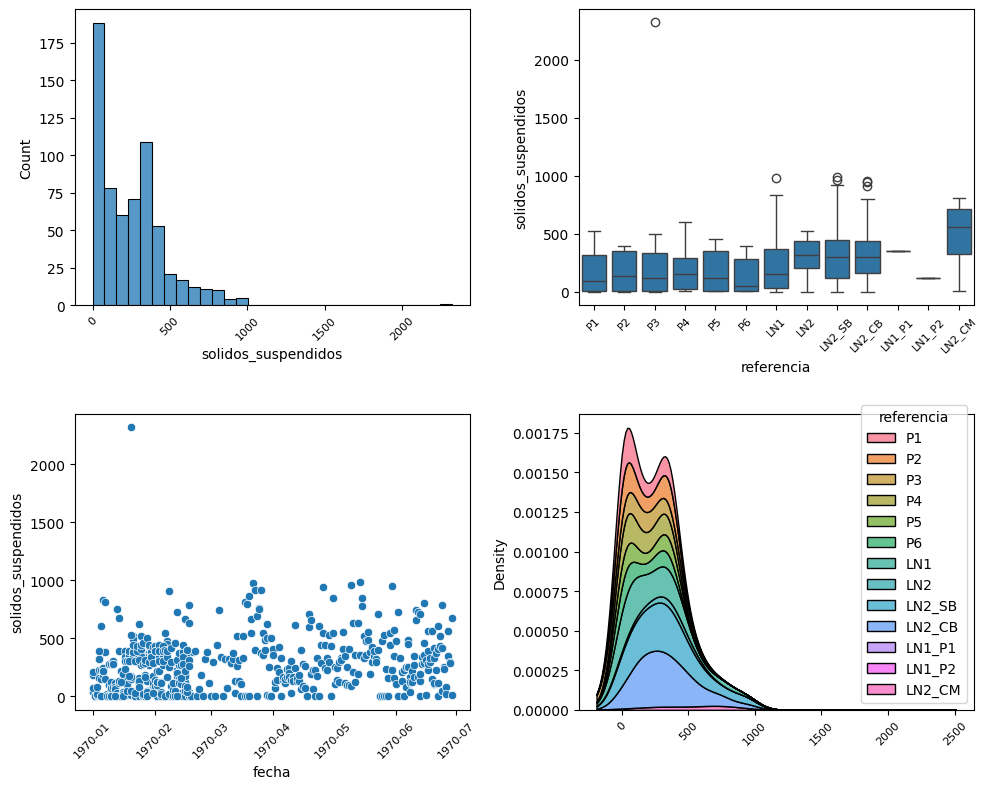

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


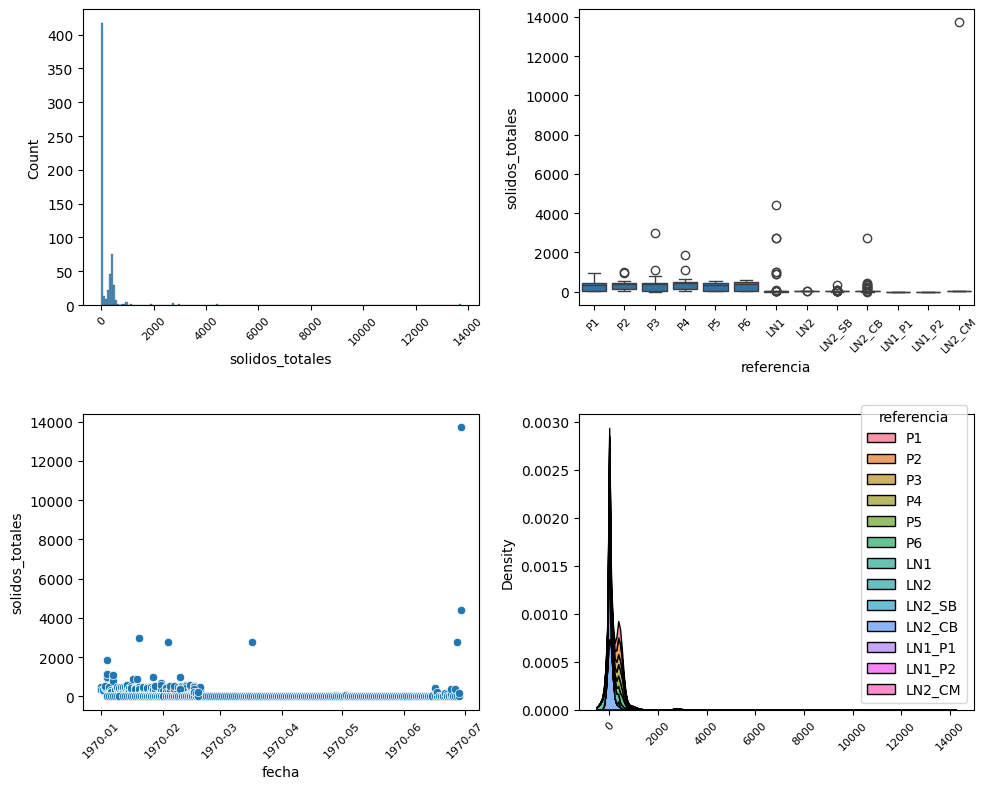

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


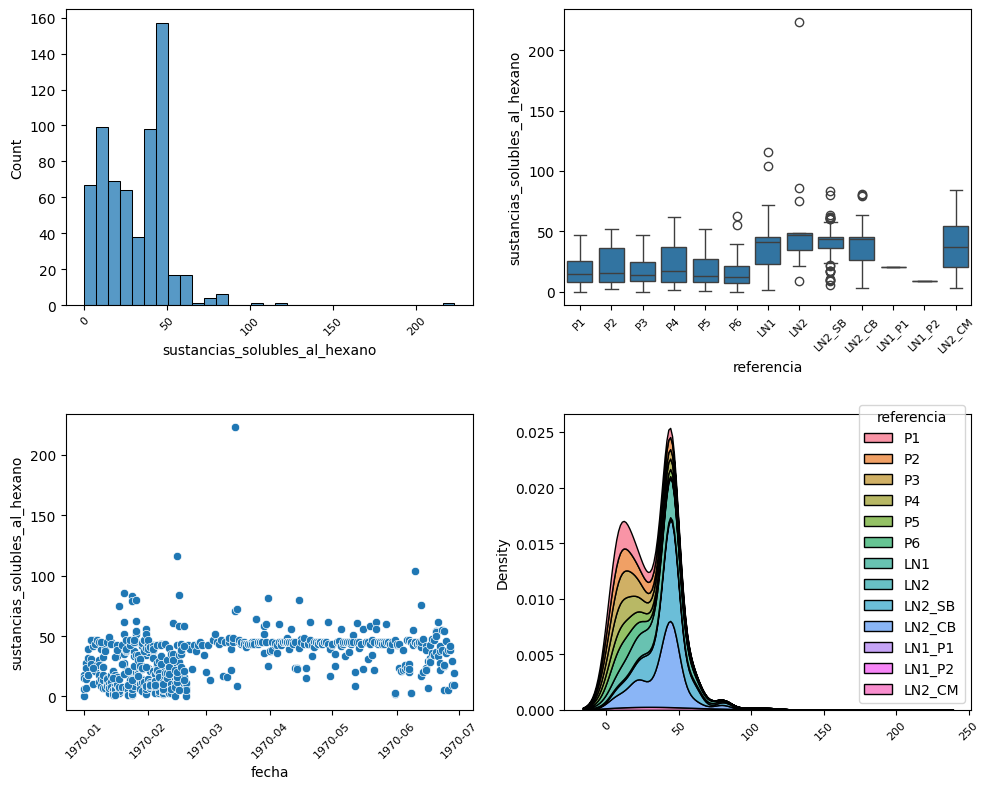

C:\Users\mikdevio\AppData\Local\Temp\ipykernel_10760\2400587335.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


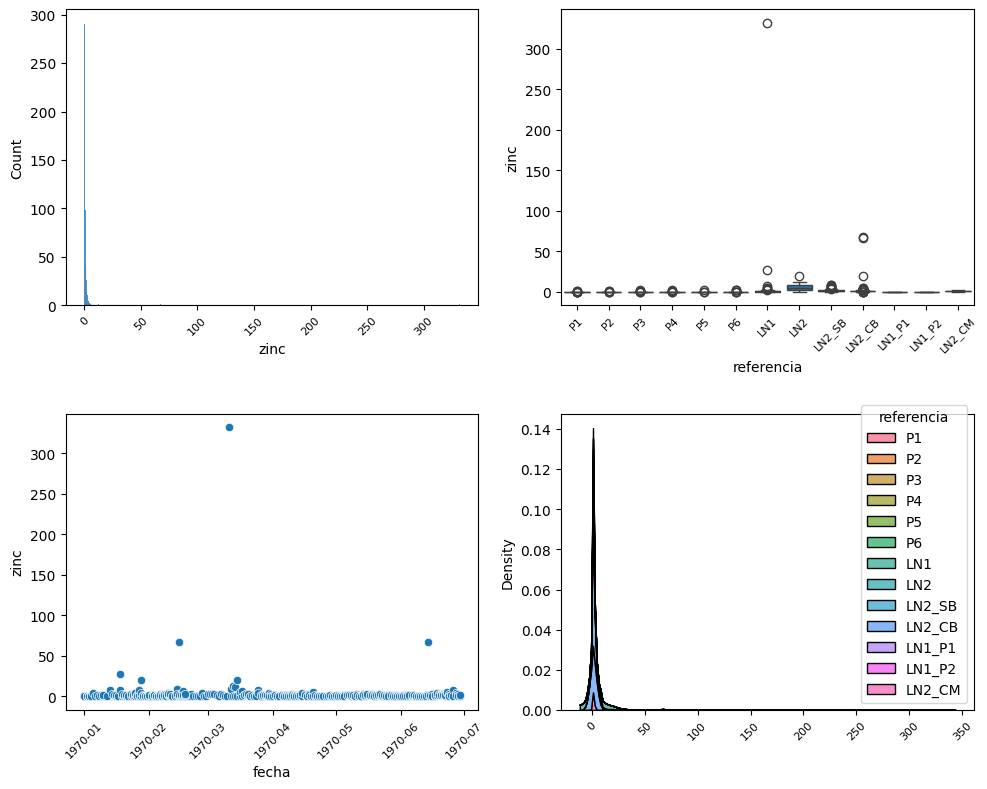

In [ ]:

column_names = data_fixed.drop(columns=['fecha', 'referencia']).columns.to_list()

for column_name in column_names:

    fig_1, axes_1 = plt.subplots(2, 2, figsize=(10, 8))
    sns.histplot(data=data_fixed, x=column_name, ax=axes_1[0, 0])
    sns.boxplot(data=data_fixed, x='referencia', y=column_name, ax=axes_1[0, 1])
    sns.scatterplot(data=data_fixed, x='fecha', y=column_name, ax=axes_1[1, 0])
    sns.kdeplot(
        data=data_fixed,
        x=column_name,
        bw_adjust=1,
        hue="referencia",
        multiple="stack",
        ax=axes_1[1, 1],

    )

    axes_1[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes_1[1, 0].xaxis.set_major_locator(mdates.MonthLocator())

    # axes_1[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    # axes_1[1, 1].xaxis.set_major_locator(mdates.MonthLocator())
    axes_1[1, 1].set(xlabel=None)

    for ax in axes_1.flat:
        ax.tick_params(axis='x', rotation=45, labelsize=8)

    plt.tight_layout()  # Prevents overlapv
    plt.savefig(f'./graphs/initial/initial_{column_name}.png')
    plt.show()


### Preparación Obligatoria: Estandarización

El PCA es extremadamente sensible a las escalas. Si la DQO tiene valores de 500 y el pH de 7, el PCA creerá que la DQO es más importante solo por ser un número más grande. Debes llevar todo a la misma escala (media 0, varianza 1).

In [ ]:
# Análisis de Componentes Principales (PCA)
# 1. Seleccionamos solo las columnas numéricas que sobrevivieron a la limpieza
df_numeric = data_fixed.select_dtypes(include=[np.number])

# 2. Estandarización (Crucial para PCA)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric)

### Aplicar el PCA

No sabemos cuántos componentes necesitamos inicialmente, así que primero ajustamos el modelo con todos para analizar la Varianza Explicada.

In [ ]:
# Inicializamos PCA sin límite de componentes para analizar
pca_model = PCA()
pca_data = pca_model.fit_transform(data_scaled)

# Calculamos la varianza acumulada
varianza_acumulada = np.cumsum(pca_model.explained_variance_ratio_)

# Buscamos cuántos componentes necesitamos para cubrir, por ejemplo, el 85% de la info
n_componentes = np.argmax(varianza_acumulada >= 0.85) + 1
print(f"Necesitas {n_componentes} componentes para explicar el 85% de los datos.")

Necesitas 14 componentes para explicar el 85% de los datos.


### Reducción Final y Visualización

Una vez que sabes cuántos componentes son útiles (supongamos que son 3), transformas tu base de datos original en una nueva tabla mucho más ligera para tu ANN.

In [ ]:
# Aplicamos PCA con el número óptimo de componentes
pca_final = PCA(n_components=n_componentes)
componentes_principales = pca_final.fit_transform(data_scaled)

# Convertimos a DataFrame para que sea fácil de usar en la ANN
df_pca = pd.DataFrame(
    data=componentes_principales, 
    columns=[f'PC{i+1}' for i in range(n_componentes)]
)

# Recuperar columnas de identificación (opcional pero recomendado)
# Si 'data_fixed' mantiene el mismo orden de filas:
df_pca.insert(0, 'fecha', data_fixed['fecha'].values)
df_pca.insert(1, 'referencia', data_fixed['referencia'].values)

# Guardar el archivo en tu directorio actual
nombre_archivo = "./results/pca_data.csv"
df_pca.to_csv(nombre_archivo, index=False, sep=',', encoding='utf-8')
print(f"¡Archivo guardado con éxito como: {nombre_archivo}!")

df_pca.head()

¡Archivo guardado con éxito como: ./results/pca_data.csv!


,fecha,referencia,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
0,04/06/2001,P1,-3.326322,-0.552963,0.485198,-0.312728,-0.542538,0.115474,0.335675,-0.206634,0.242639,-1.872864,0.210086,0.578835,-0.582403,-0.086120
1,04/06/2001,P2,-3.036638,-0.399773,0.505980,0.079480,-0.830813,-0.181224,0.258040,0.249926,0.106522,-1.618426,0.269490,0.437389,-0.540241,0.613134
2,04/06/2001,P3,-2.810566,-0.264544,0.808863,-0.006687,-0.840499,0.018444,-0.232837,0.146264,-0.160233,-1.926390,-0.080844,0.218222,-0.782170,0.477851
3,04/06/2001,P4,-3.251007,-0.415525,0.539191,-0.218556,-0.649170,0.039671,0.375520,-0.068423,0.235019,-1.762503,0.188824,0.584198,-0.521870,0.133320
4,04/07/2001,P1,-2.835899,-0.046641,0.331455,-0.554034,-0.162970,0.180875,-0.022183,-0.677784,-0.109154,0.214563,-0.201085,-0.407507,0.091338,0.147521


### Extraer los "Loadings" del PCA

Después de ajustar tu PCA, puedes acceder a la matriz components_.

In [ ]:
# Suponiendo que 'pca_final' es tu objeto PCA ya entrenado
# y 'data_numeric_only' son tus columnas originales antes de la transformación

loadings = pd.DataFrame(
    pca_final.components_.T,           # Transponemos la matriz de componentes
    columns=[f'PC{i+1}' for i in range(n_componentes)], # Nombres de los PCs
    index=df_numeric.columns    # Nombres de tus químicos/variables
)

# Mostramos las variables que más influyen en el PC1
# print(loadings['PC2'].sort_values(ascending=False))
display(loadings)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
aluminio,-0.024123,-0.172203,-0.114683,0.597356,-0.003194,0.199386,-0.156905,0.149341,-0.020792,0.073983,-0.197456,0.084017,0.180024,-0.242610
cadmio,0.123311,-0.253738,-0.233459,-0.260520,0.145249,0.203183,-0.151171,0.240832,-0.045619,0.051542,-0.389053,0.552884,0.124928,0.201301
cianuro_libre,0.018941,0.076730,-0.002038,0.191558,0.415380,-0.220241,0.505484,0.301325,0.320301,0.096710,0.152087,0.351003,-0.162464,-0.224104
cobre,0.269913,0.049563,-0.117934,0.127831,0.073820,0.165074,0.095254,-0.253216,0.080594,0.015759,0.410250,0.219000,0.020745,0.458314
coliformes_termotolerantes,0.124434,-0.295697,0.555206,-0.025956,-0.129937,0.141537,0.068733,0.054341,0.054840,0.158771,0.042146,0.059936,0.008214,-0.039955
coliformes_totales,0.126995,-0.269043,0.552806,-0.015030,-0.126077,0.181010,0.034207,-0.001310,0.060982,0.163867,0.091989,0.080104,0.126422,-0.028467
conductividad,0.170368,0.121225,-0.080425,-0.011491,0.347581,-0.004469,-0.060103,-0.185223,-0.055192,0.762064,-0.154300,-0.304449,0.138508,-0.133210
cromo,0.349214,0.235590,-0.048906,-0.029905,0.039025,0.250680,-0.101104,-0.213361,-0.037589,-0.058382,-0.011809,0.093674,-0.081527,-0.079741
dbo5,0.086235,0.207487,-0.063786,-0.114580,-0.109473,0.499794,0.304113,0.462923,0.124040,-0.117028,-0.116303,-0.442900,0.003245,0.013564
dqo,-0.026633,-0.194158,-0.094633,-0.105540,0.253523,0.113552,-0.478495,0.434589,-0.144739,0.095218,0.578456,-0.125751,-0.220202,-0.010739


### Interpretación:
- Valores cercanos a 1 o -1: Indican que la variable tiene una influencia muy fuerte en ese componente.
- Valores cercanos a 0: Indican que la variable no aporta casi nada a ese componente.
- Signo (+ o -): Indica la dirección de la relación. Si el PC1 tiene un loading alto positivo para aluminio y hierro, significa que cuando el PC1 sube, ambos metales suelen subir juntos.

### Visualización con un Mapa de Calor (Heatmap)

La forma más fácil de "leer" tu nueva base de datos es con un mapa de calor. Esto te permitirá ver de un vistazo qué parámetros químicos definen cada componente.

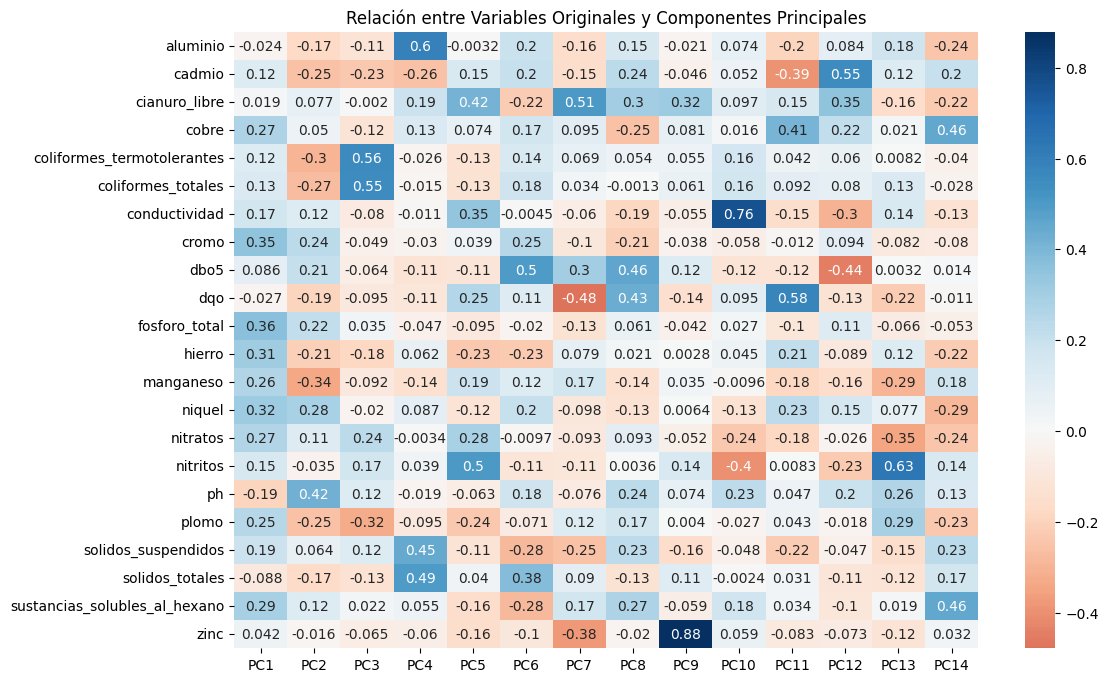

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title('Relación entre Variables Originales y Componentes Principales')
plt.savefig('./graphs/initial/var_cpa.png')
plt.show()

In [ ]:
# Guardando componentes para pretratamiento
joblib.dump(scaler, './binary/scaler_obj.joblib')
joblib.dump(pca_final, './binary/pca_obj.joblib')

['./binary/pca_obj.joblib']